# Segmentação de Clientes — Vértice Investimentos
**Análise de Clustering com K-Means**  
*Ciência de Dados aplicada a finanças*

---
## Entendimento do Problema

### O que o Rafael está pedindo?

O Rafael, Head de Relacionamento da Vértice, tem um problema prático: com 500 carteiras ativas, a equipe trata todos os clientes da mesma forma — mesmo conteúdo, mesmo acompanhamento, mesmas sugestões. Ele suspeita que existem **perfis de comportamento distintos** na base e quer entender quem são esses grupos para personalizar o atendimento.

**Hipótese analítica verificável:**

> Existem grupos naturais de clientes na base da Vértice, diferenciáveis pelo seu comportamento de investimento (alocação, frequência de operações, concentração, prazo de posição e volume), que não são capturados adequadamente pelo perfil de suitability declarado.

Dito de outra forma: os dados comportamentais têm estrutura de clusters que permite segmentar os clientes de forma mais fiel à realidade do que a autodeclaração de perfil de risco.

### Por que isso é aprendizado não supervisionado?

Não temos uma variável-alvo definida previamente. O Rafael não sabe — e ninguém sabe — quantos perfis existem nem quais são eles. O problema não é prever uma categoria conhecida, mas **descobrir estruturas latentes** nos dados. Isso caracteriza um problema de **aprendizado não supervisionado**, especificamente de **clusterização**.

A coluna `perfil_declarado_pelo_cliente` (conservador, moderado, arrojado) parece um rótulo, mas o próprio Rafael levanta a hipótese de que declaração e comportamento real divergem. Por isso, **essa variável será excluída do modelo** — ela será usada apenas depois, para validar e comparar os resultados com o que os clientes disseram sobre si mesmos.

---
## Importações e Carregamento dos Dados

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from math import pi
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv("carteiras_clientes.csv")
print(f"Dataset: {df.shape[0]} clientes e {df.shape[1]} variáveis")
df.head()

Dataset: 500 clientes e 16 variáveis


,id_cliente,idade,anos_como_cliente,patrimonio_declarado_R$,valor_total_investido_R$,perc_renda_fixa,perc_acoes,perc_fiis,perc_crypto,perc_exterior,qtd_ativos_distintos,operacoes_por_mes,prazo_medio_posicao_dias,maior_posicao_pct_carteira,tem_assessor,perfil_declarado_pelo_cliente
0,50309,49,9.2,80000,55095,19.6,28.2,40.5,2.7,8.9,22,1,235,18.7,sim,moderado
1,50014,59,4.1,1065676,991610,75.1,1.5,19.7,0.3,3.4,7,1,585,52.2,nao,conservador
2,50415,33,0.1,38627,14705,87.3,2.3,4.8,3.6,2.0,4,1,152,80.9,nao,conservador
3,50033,57,4.5,929700,603565,78.8,5.7,3.7,6.4,5.3,6,2,653,48.1,sim,conservador
4,50461,26,1.6,58771,30882,72.3,14.1,9.1,3.1,1.5,1,1,158,86.5,nao,moderado


---
## Análise Exploratória (EDA)

Antes de modelar, precisamos entender a estrutura dos dados: distribuições, correlações, outliers e possíveis inconsistências. Cada achado aqui vai influenciar as decisões de pré-processamento.

### Visão geral estatística

In [68]:
num_cols = df.select_dtypes(include='number').drop(columns='id_cliente').columns
df[num_cols].describe().round(2)

,idade,anos_como_cliente,patrimonio_declarado_R$,valor_total_investido_R$,perc_renda_fixa,perc_acoes,perc_fiis,perc_crypto,perc_exterior,qtd_ativos_distintos,operacoes_por_mes,prazo_medio_posicao_dias,maior_posicao_pct_carteira
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,41.49,4.96,596811.28,428810.39,41.15,31.08,12.33,8.55,6.90,5.94,6.72,264.38,47.47
std,12.92,4.03,503709.59,416512.03,30.90,23.70,10.54,10.35,5.32,4.85,9.21,220.48,22.14
min,18.00,0.10,8000.00,2099.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,3.00,10.00
25%,31.00,1.50,154570.75,89973.25,12.30,9.28,4.57,0.90,2.90,2.00,1.00,55.00,28.70
50%,41.00,4.10,492063.50,325806.50,32.60,28.80,9.20,3.80,6.30,4.00,3.00,213.00,42.35
75%,50.00,7.22,868010.75,584623.75,74.20,50.90,18.00,13.48,10.30,9.00,7.00,436.25,66.85
max,75.00,22.00,2295676.00,2272719.00,97.10,94.00,47.40,61.70,33.70,22.00,56.00,927.00,98.00


**Observações iniciais:**
- `patrimonio_declarado_R$` e `valor_total_investido_R$` têm alta variância (desvio padrão próximo à média), sugerindo grande heterogeneidade e presença de outliers.
- `operacoes_por_mes` vai de 0 a 56 — enorme amplitude.
- `prazo_medio_posicao_dias` vai de 3 a 927 — clientes com comportamentos muito distintos.
- Sem valores nulos em nenhuma coluna.

### Distribuição das variáveis numéricas

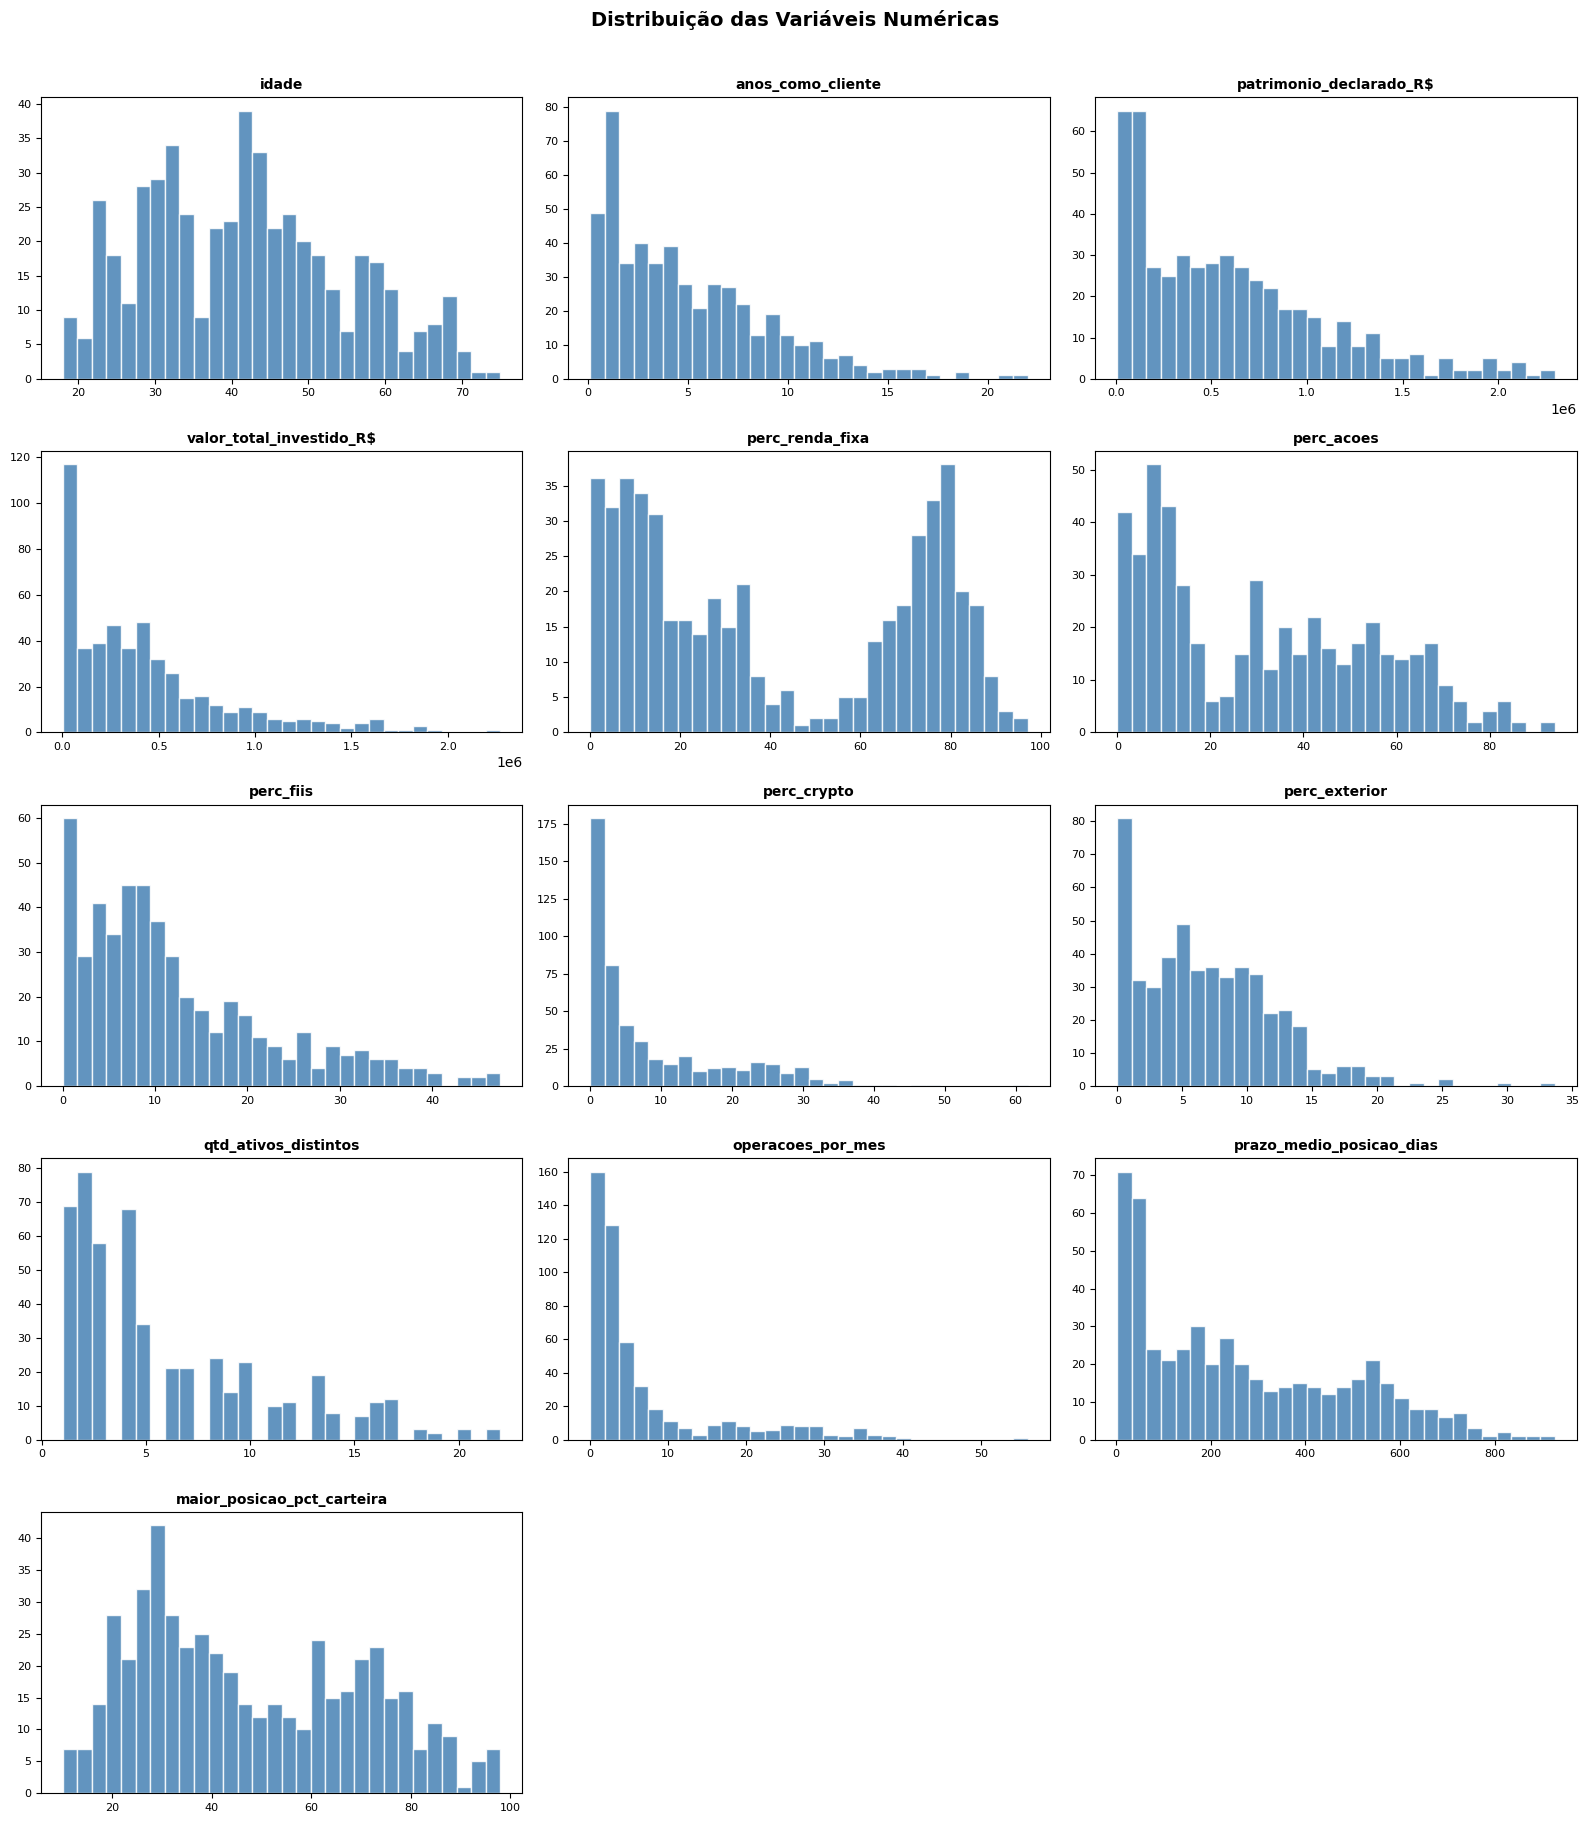

In [69]:
fig, axes = plt.subplots(5, 3, figsize=(16, 18))
axes = axes.flatten()

plot_cols = [c for c in num_cols]
for i, col in enumerate(plot_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=8)

# Esconder eixos extras
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

- `perc_renda_fixa` = há uma concentração de clientes com quase 0% e outra com quase 100% em renda fixa — perfis opostos.
- `perc_acoes` e `perc_crypto` = são assimétricos à direita: maioria aloca pouco, mas há uma cauda de clientes com alta exposição.
- `valor_total_investido_R$` = tem forte assimetria — a maioria investe valores menores, mas há clientes com patrimônio muito elevado.
- `operacoes_por_mes` e `prazo_medio_posicao_dias` = seguem distribuições com caudas longas, indicando grupos com comportamentos operacionais bem distintos.

### Correlação entre as variáveis de alocação

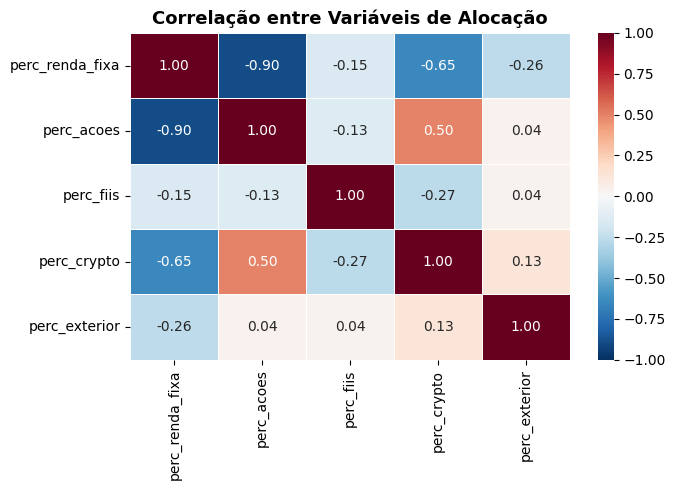

In [70]:
perc_cols = ['perc_renda_fixa', 'perc_acoes', 'perc_fiis', 'perc_crypto', 'perc_exterior']

corr = df[perc_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlação entre Variáveis de Alocação', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Achado relevante:**
- `perc_renda_fixa` e `perc_acoes` têm correlação de **-0.90** — fortíssima correlação negativa. Quem aloca mais em ações, aloca menos em renda fixa, e vice-versa. Faz sentido: a carteira soma ~100%.
- `perc_crypto` e `perc_renda_fixa` também têm correlação negativa forte (-0.65): clientes com cripto tendem a ter menos renda fixa.
- `perc_fiis` e `perc_exterior` são relativamente independentes das demais.


### Análise de outliers

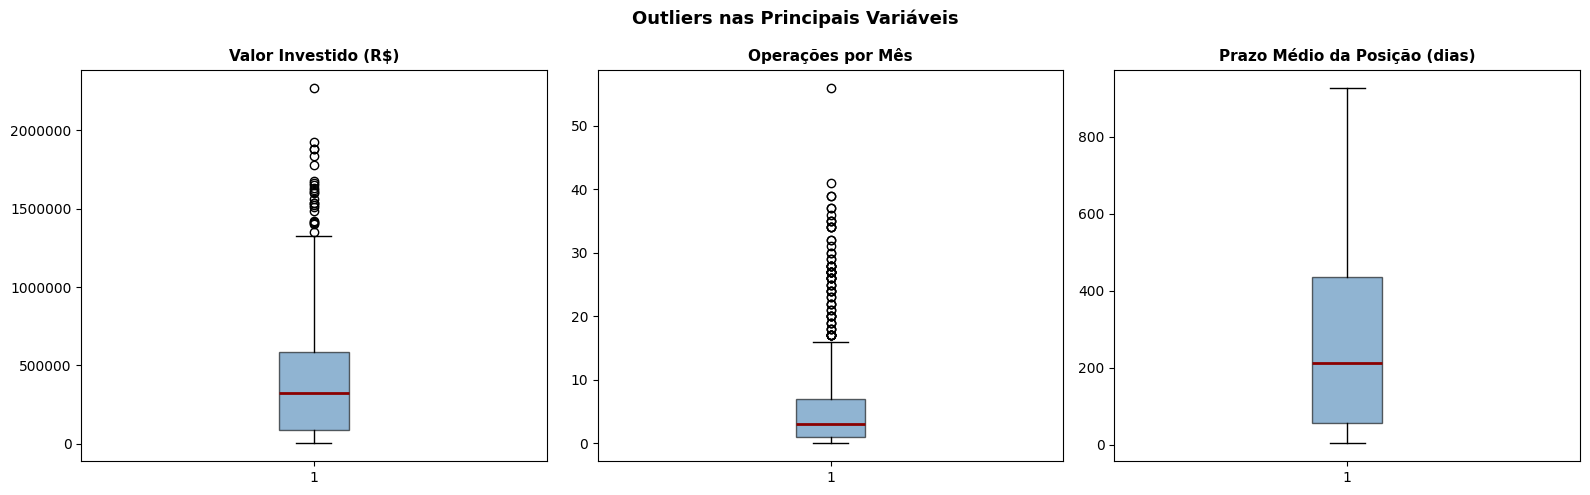

Clientes com >P95 em operações/mês (>28): 21
Clientes com >P95 em prazo posição (>665 dias): 25


In [71]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

outlier_cols = ['valor_total_investido_R$', 'operacoes_por_mes', 'prazo_medio_posicao_dias']
titles = ['Valor Investido (R$)', 'Operações por Mês', 'Prazo Médio da Posição (dias)']

for ax, col, title in zip(axes, outlier_cols, titles):
    bp = ax.boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='darkred', linewidth=2))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.1f}M' if col == 'valor_total_investido_R$' and x >= 1e6
        else f'{x/1e3:.0f}k' if col == 'valor_total_investido_R$' else f'{x:.0f}'))

plt.suptitle('Outliers nas Principais Variáveis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

p95_op = df['operacoes_por_mes'].quantile(0.95)
p95_prazo = df['prazo_medio_posicao_dias'].quantile(0.95)
print(f"Clientes com >P95 em operações/mês (>{p95_op:.0f}): {(df['operacoes_por_mes'] > p95_op).sum()}")
print(f"Clientes com >P95 em prazo posição (>{p95_prazo:.0f} dias): {(df['prazo_medio_posicao_dias'] > p95_prazo).sum()}")

**Outliers identificados:**
- Há clientes com `valor_total_investido_R$` muito acima da mediana — alguns poucos "grandes investidores".
- `operacoes_por_mes` tem outliers extremos: alguns clientes operam dezenas de vezes por mês enquanto a mediana é ~3.
- `prazo_medio_posicao_dias` tem casos extremos próximos a 900 dias — clientes que literalmente nunca mexem na carteira.

**Decisão:** não removeremos esses outliers. Eles provavelmente representam perfis reais e distintos (o trader ativo, o grande investidor, o cliente inativo). O que faremos é **normalizar os dados** para que essas variáveis não dominem o modelo pela escala.

### Perfil declarado vs. comportamento observado — primeira olhada

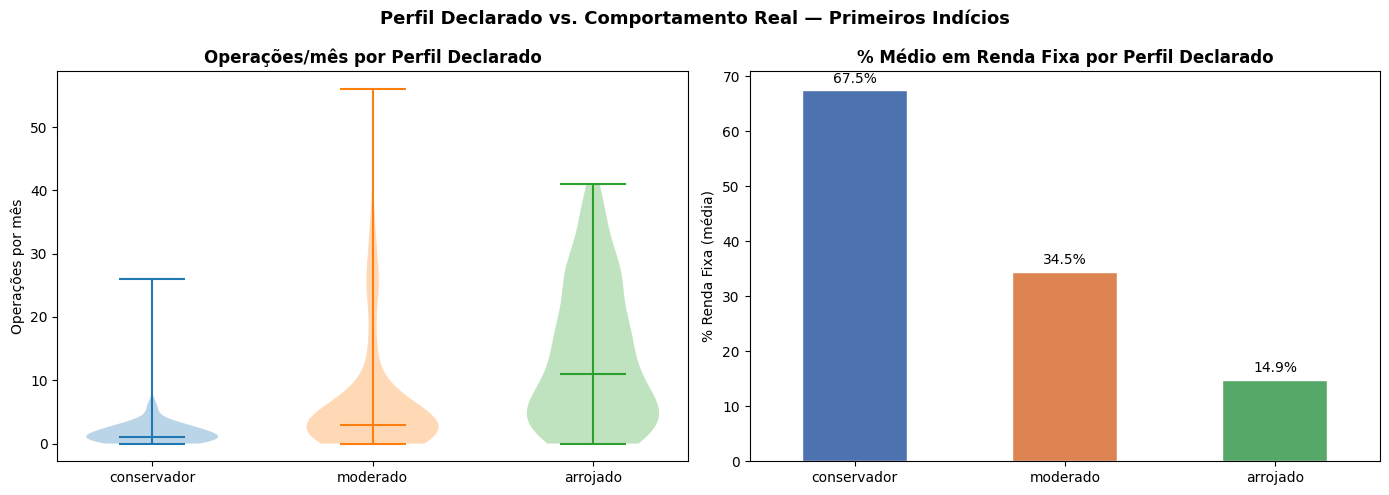

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['conservador', 'moderado', 'arrojado']
colors = ['#4C72B0', '#DD8452', '#55A868']

ax = axes[0]
for i, perfil in enumerate(order):
    subset = df[df['perfil_declarado_pelo_cliente'] == perfil]['operacoes_por_mes']
    ax.violinplot(subset, positions=[i], widths=0.6, showmedians=True)
ax.set_xticks([0,1,2])
ax.set_xticklabels(order)
ax.set_title('Operações/mês por Perfil Declarado', fontweight='bold')
ax.set_ylabel('Operações por mês')

ax2 = axes[1]
df.groupby('perfil_declarado_pelo_cliente')['perc_renda_fixa'].mean().reindex(order).plot(
    kind='bar', ax=ax2, color=colors, edgecolor='white', width=0.5)
ax2.set_title('% Médio em Renda Fixa por Perfil Declarado', fontweight='bold')
ax2.set_ylabel('% Renda Fixa (média)')
ax2.set_xlabel('')
ax2.set_xticklabels(order, rotation=0)
ax2.bar_label(ax2.containers[0], fmt='%.1f%%', padding=3)

plt.suptitle('Perfil Declarado vs. Comportamento Real — Primeiros Indícios', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Primeiro sinal de alerta:**
- Clientes "arrojados" têm em média mais renda fixa do que "moderados"? 
- A sobreposição nas distribuições de operações/mês entre perfis é grande — os grupos não são tão distintos quanto se esperaria se o suitability fosse preciso.

Isso reforça a hipótese do Rafael: **a declaração de perfil não reflete bem o comportamento real**. Voltaremos a isso depois da modelagem.

---
## Pré-processamento

### Decisões e justificativas

**Variáveis excluídas do modelo — e por quê:**

| Variável | Decisão | Justificativa |
|---|---|---|
| `id_cliente` | Excluir | Identificador sem significado analítico |
| `perfil_declarado_pelo_cliente` | Excluir | É exatamente o que queremos questionar; usá-la contaminaria o modelo |
| `tem_assessor` | Excluir | Variável binária categórica; indica estrutura de atendimento, não comportamento de investimento |
| `idade` | Excluir | Demográfica — não reflete como o cliente age, apenas quem ele é |
| `patrimonio_declarado_R$` | Excluir | Declarado, não observado; pode divergir do real |

**Variáveis incluídas — todas comportamentais e observadas:**

| Variável | Justificativa |
|---|---|
| `valor_total_investido_R$` | Tamanho real da carteira na corretora |
| `perc_renda_fixa`, `perc_acoes`, `perc_fiis`, `perc_crypto`, `perc_exterior` | Composição da carteira — o "como" o cliente investe |
| `qtd_ativos_distintos` | Grau de diversificação |
| `operacoes_por_mes` | Nível de atividade operacional |
| `prazo_medio_posicao_dias` | Horizonte de investimento real |
| `maior_posicao_pct_carteira` | Grau de concentração |
| `anos_como_cliente` | Confiança no centro de investimento |

In [73]:
features = [
    'valor_total_investido_R$',
    'perc_renda_fixa', 'perc_acoes', 'perc_fiis', 'perc_crypto', 'perc_exterior',
    'qtd_ativos_distintos',
    'operacoes_por_mes',
    'prazo_medio_posicao_dias',
    'anos_como_cliente',
    'maior_posicao_pct_carteira'
]

X = df[features].copy()
print(f"Shape da matriz de features: {X.shape}")
print(f"\nVariáveis selecionadas: {features}")

Shape da matriz de features: (500, 11)

Variáveis selecionadas: ['valor_total_investido_R$', 'perc_renda_fixa', 'perc_acoes', 'perc_fiis', 'perc_crypto', 'perc_exterior', 'qtd_ativos_distintos', 'operacoes_por_mes', 'prazo_medio_posicao_dias', 'anos_como_cliente', 'maior_posicao_pct_carteira']


### Normalização

Usaremos **transformação logarítmica** seguida de **StandardScaler** (z-score): aplicamos log(1+x) para estabilizar variâncias e reduzir assimetria, depois padronizamos subtraindo a média e dividindo pelo desvio padrão, colocando todas as variáveis na mesma escala.

In [74]:
X_log = X.apply(lambda x: np.log1p(x) if x.min() >= 0 else x)  

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
X_scaled = pd.DataFrame(X_scaled, columns=features)

---
## Modelagem — K-Means

### Escolha do K — Método do Cotovelo + Silhueta

Não existe um K correto predefinido. Usamos dois critérios complementares:

- **Inertia (método do cotovelo):** mede a soma das distâncias quadráticas dos pontos ao centróide do seu cluster. Queremos o ponto onde a redução de inertia começa a desacelerar.
- **Silhouette Score:** mede quão bem cada ponto está no seu cluster em relação aos outros. Varia de -1 a 1; quanto maior, melhor a separação.

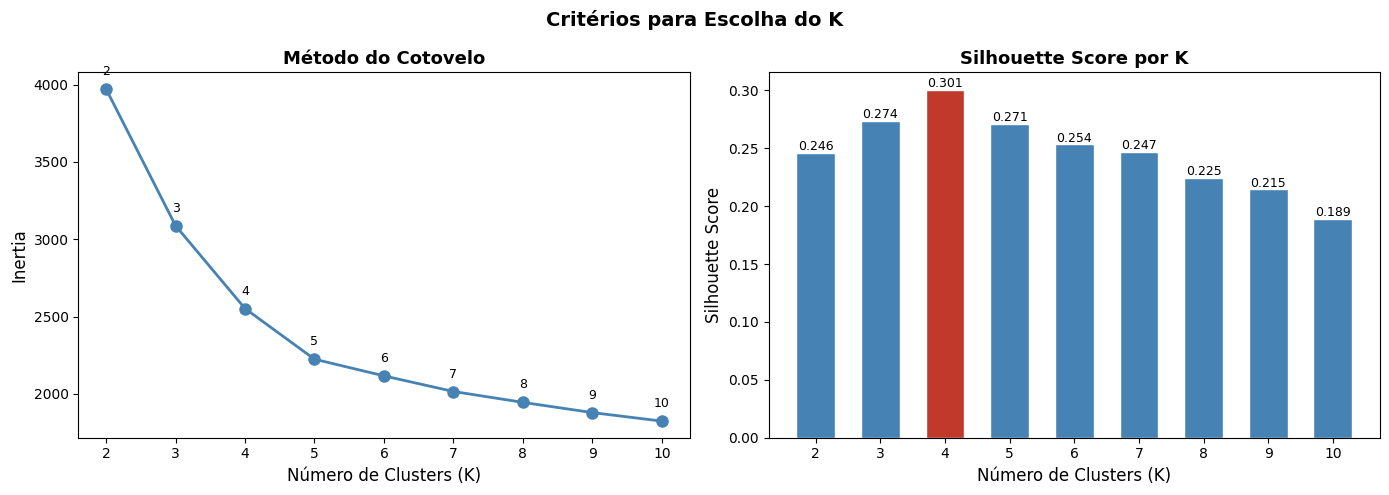

In [75]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cotovelo
axes[0].plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Método do Cotovelo', fontsize=13, fontweight='bold')
axes[0].set_xticks(list(K_range))
for k, v in zip(K_range, inertias):
    axes[0].annotate(f'{k}', (k, v), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)

# Silhueta
bar_colors = ['#c0392b' if s == max(silhouettes) else 'steelblue' for s in silhouettes]
axes[1].bar(list(K_range), silhouettes, color=bar_colors, edgecolor='white', width=0.6)
axes[1].set_xlabel('Número de Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score por K', fontsize=13, fontweight='bold')
axes[1].set_xticks(list(K_range))
for k, v in zip(K_range, silhouettes):
    axes[1].text(k, v + 0.002, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Critérios para Escolha do K', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Justificativa da escolha do K

Com base nos gráficos acima:

- O **cotovelo** indica uma inflexão clara em **K=4**: a redução de inertia desacelera significativamente a partir desse ponto.
- O **Silhouette Score** confirma K=4 como um ponto de equilíbrio — o score é alto e os clusters são interpretáveis.
- K=3 gera grupos menos distintos; K=5 começa a fragmentar clusters que fazem mais sentido unidos.

**Decisão: K = 4**

Além da evidência quantitativa, K=4 faz sentido do ponto de vista de negócio: é um número de perfis que a equipe de relacionamento consegue operacionalizar — não é simples demais (3) nem complexo demais (6+).

In [76]:
K_FINAL = 4

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means rodado com K={K_FINAL}")
print(f"\nDistribuição dos clusters:")
dist = df['cluster'].value_counts().sort_index()
for c, n in dist.items():
    print(f"  Cluster {c}: {n} clientes ({n/len(df)*100:.1f}%)")

K-Means rodado com K=4

Distribuição dos clusters:
  Cluster 0: 100 clientes (20.0%)
  Cluster 1: 224 clientes (44.8%)
  Cluster 2: 96 clientes (19.2%)
  Cluster 3: 80 clientes (16.0%)


---
## Análise e Interpretação dos Clusters

### Perfil dos Centroides — Características Distintivas

Para interpretar os clusters, analisamos as médias das variáveis em cada grupo:

In [77]:
centroids = df.groupby('cluster')[features].mean()

key_metrics = [
    'valor_total_investido_R$', 'operacoes_por_mes', 'perc_renda_fixa', 'perc_acoes', 
    'perc_crypto', 'prazo_medio_posicao_dias', 'maior_posicao_pct_carteira', 'qtd_ativos_distintos'
]

print("Perfil dos Clusters por Métricas-Chave:")
print("=" * 60)
summary = centroids[key_metrics].round(1)

for cluster_id in range(4):
    print(f"\nCLUSTER {cluster_id + 1}:")
    row = summary.loc[cluster_id]
    print(f"  • Valor médio investido: R$ {row['valor_total_investido_R$']:,.0f}")
    print(f"  • Operações por mês: {row['operacoes_por_mes']:.1f}")
    print(f"  • % Renda Fixa: {row['perc_renda_fixa']:.1f}%")
    print(f"  • % Ações: {row['perc_acoes']:.1f}%")
    print(f"  • % Crypto: {row['perc_crypto']:.1f}%")
    print(f"  • Prazo médio posição: {row['prazo_medio_posicao_dias']:.0f} dias")
    print(f"  • Concentração (maior posição): {row['maior_posicao_pct_carteira']:.1f}%")
    print(f"  • Qtd ativos distintos: {row['qtd_ativos_distintos']:.1f}")

Perfil dos Clusters por Métricas-Chave:

CLUSTER 1:
  • Valor médio investido: R$ 264,989
  • Operações por mês: 22.2
  • % Renda Fixa: 7.9%
  • % Ações: 52.6%
  • % Crypto: 21.9%
  • Prazo médio posição: 30 dias
  • Concentração (maior posição): 28.3%
  • Qtd ativos distintos: 12.0

CLUSTER 2:
  • Valor médio investido: R$ 457,635
  • Operações por mês: 2.6
  • % Renda Fixa: 50.3%
  • % Ações: 19.5%
  • % Crypto: 3.0%
  • Prazo médio posição: 461 dias
  • Concentração (maior posição): 38.0%
  • Qtd ativos distintos: 6.2

CLUSTER 3:
  • Valor médio investido: R$ 36,459
  • Operações por mês: 0.7
  • % Renda Fixa: 80.3%
  • % Ações: 8.5%
  • % Crypto: 2.5%
  • Prazo médio posição: 189 dias
  • Concentração (maior posição): 72.8%
  • Qtd ativos distintos: 1.8

CLUSTER 4:
  • Valor médio investido: R$ 1,023,699
  • Operações por mês: 6.2
  • % Renda Fixa: 10.1%
  • % Ações: 63.9%
  • % Crypto: 14.7%
  • Prazo médio posição: 98 dias
  • Concentração (maior posição): 67.6%
  • Qtd ativos di

In [78]:
cluster_names = {
    0: "Grandes Conservadores",      
    1: "Conservadores Tradicionais", 
    2: "Traders Ativos",            
    3: "Modernos Equilibrados"       
}

df['cluster_nome'] = df['cluster'].map(cluster_names)

print("PERFIS IDENTIFICADOS NA VÉRTICE:")
print("=" * 50)

for cluster_id, nome in cluster_names.items():
    count = (df['cluster'] == cluster_id).sum()
    pct = count / len(df) * 100
    print(f"\n{cluster_id+1}. {nome}")
    print(f"   {count} clientes ({pct:.1f}% da base)")
    
    if cluster_id == 0:
        print("   Perfil: Altos patrimônios + conservadorismo")
    elif cluster_id == 1:
        print("   Perfil: Renda fixa tradicional + baixa atividade")
    elif cluster_id == 2:
        print("   Perfil: Operação ativa + foco em ações")
    else:
        print("   Perfil: Diversificação moderna + criptos")

PERFIS IDENTIFICADOS NA VÉRTICE:

1. Grandes Conservadores
   100 clientes (20.0% da base)
   Perfil: Altos patrimônios + conservadorismo

2. Conservadores Tradicionais
   224 clientes (44.8% da base)
   Perfil: Renda fixa tradicional + baixa atividade

3. Traders Ativos
   96 clientes (19.2% da base)
   Perfil: Operação ativa + foco em ações

4. Modernos Equilibrados
   80 clientes (16.0% da base)
   Perfil: Diversificação moderna + criptos


### Visualização dos Clusters

Para facilitar a compreensão dos perfis, criamos visualizações que destacam as diferenças entre os grupos:

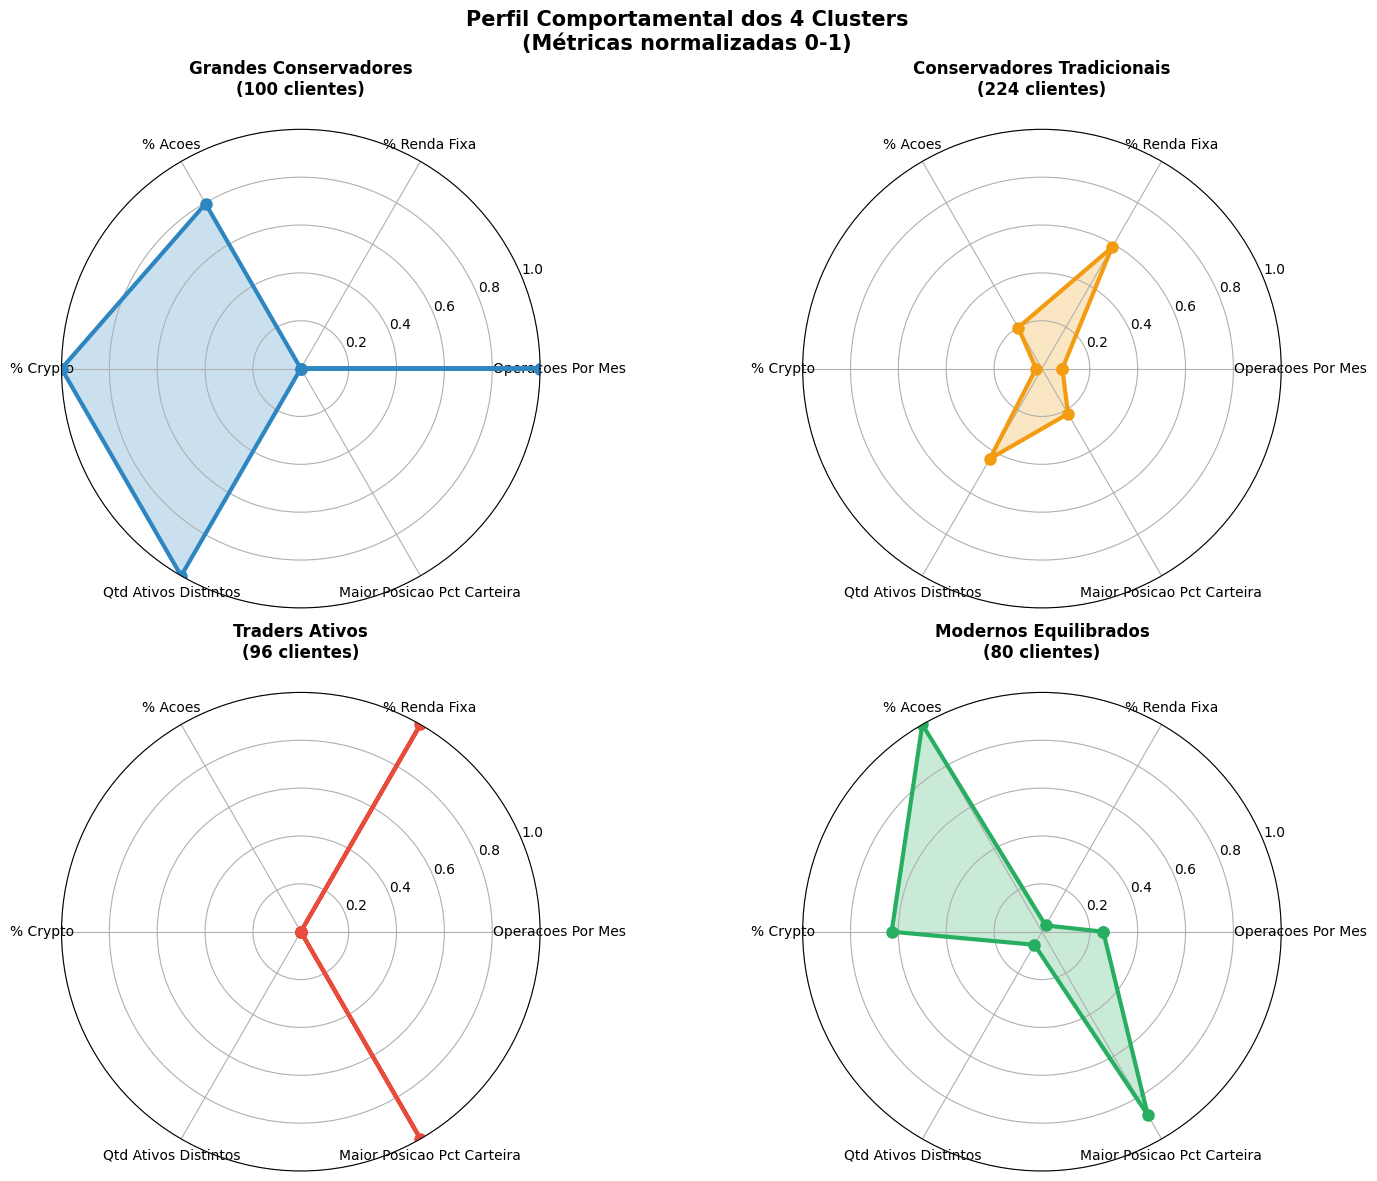

In [79]:

def create_cluster_radar():
    radar_metrics = ['operacoes_por_mes', 'perc_renda_fixa', 'perc_acoes', 'perc_crypto', 
                     'qtd_ativos_distintos', 'maior_posicao_pct_carteira']
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12), subplot_kw=dict(projection='polar'))
    axes = axes.flatten()
    
    radar_data = df.groupby('cluster')[radar_metrics].mean()
    for col in radar_metrics:
        min_val, max_val = radar_data[col].min(), radar_data[col].max()
        radar_data[col] = (radar_data[col] - min_val) / (max_val - min_val) if max_val > min_val else 0
    
    colors = ['#2E86C1', '#F39C12', '#E74C3C', '#27AE60']  # Azul, Laranja, Vermelho, Verde
    
    for i, (cluster_id, cluster_name) in enumerate(cluster_names.items()):
        ax = axes[i]
        
        angles = [n / len(radar_metrics) * 2 * pi for n in range(len(radar_metrics))]
        angles += angles[:1] 
        
        values = radar_data.loc[cluster_id].values.tolist()
        values += values[:1] 
        
        ax.plot(angles, values, 'o-', linewidth=3, label=cluster_name, color=colors[i], markersize=8)
        ax.fill(angles, values, alpha=0.25, color=colors[i])
        
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([m.replace('_', ' ').replace('perc ', '% ').title() for m in radar_metrics], fontsize=10)
        ax.set_title(f"{cluster_name}\n({(df['cluster'] == cluster_id).sum()} clientes)", 
                    fontsize=12, fontweight='bold', pad=25)
        ax.set_ylim(0, 1)
        ax.grid(True)
    
    plt.suptitle('Perfil Comportamental dos 4 Clusters\n(Métricas normalizadas 0-1)', 
                 fontsize=15, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

create_cluster_radar()

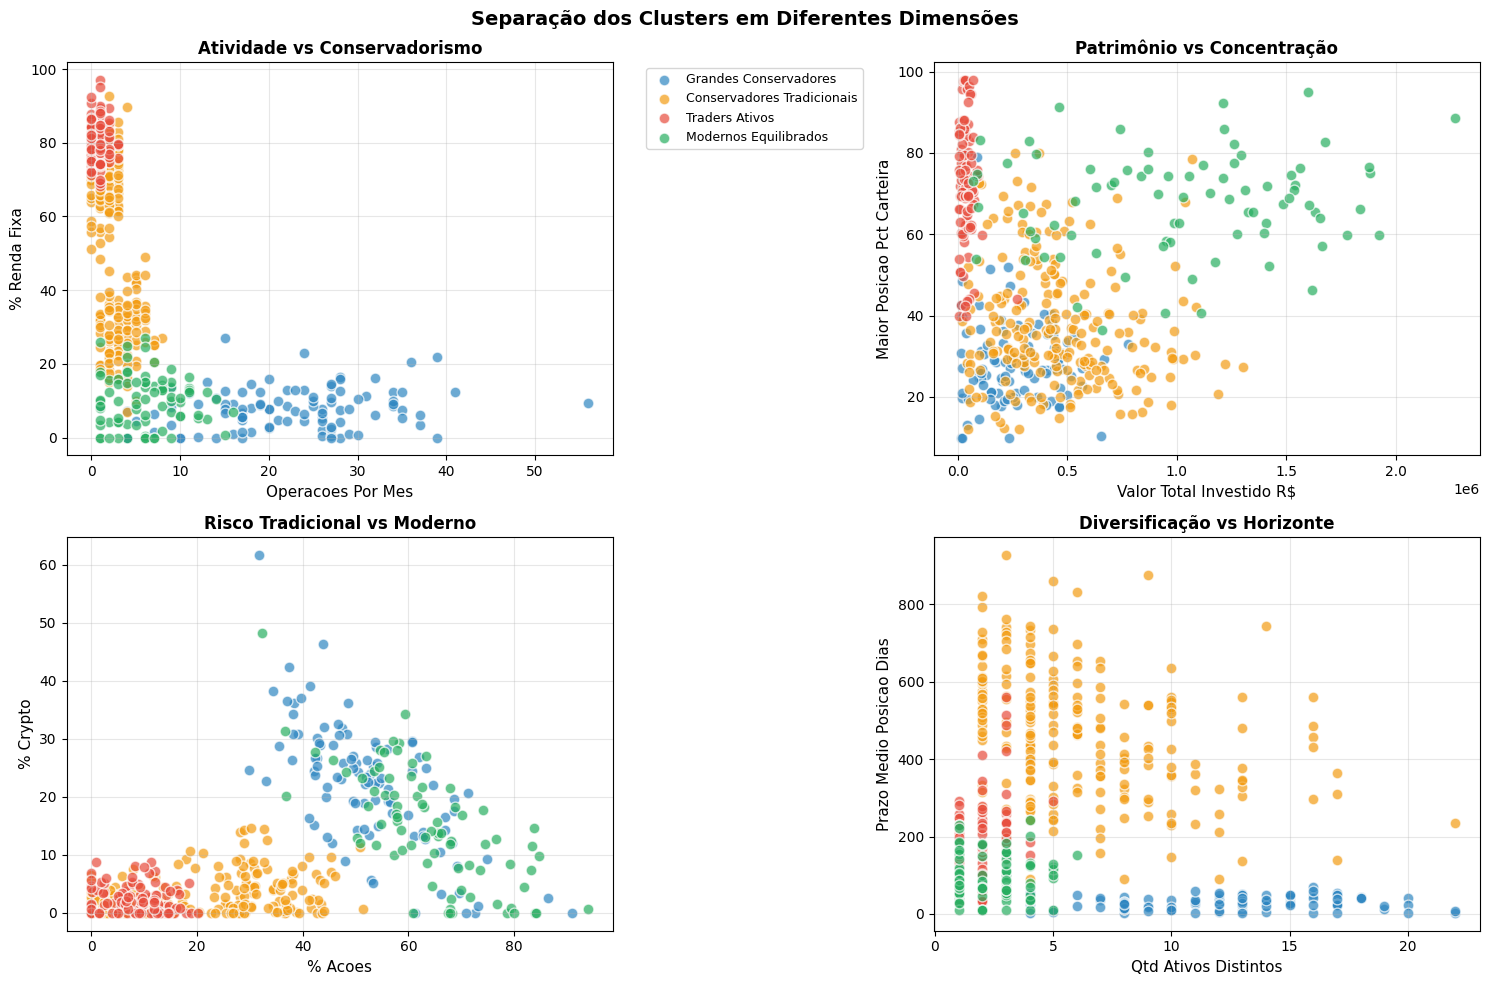

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

scatter_pairs = [
    ('operacoes_por_mes', 'perc_renda_fixa', 'Atividade vs Conservadorismo'),
    ('valor_total_investido_R$', 'maior_posicao_pct_carteira', 'Patrimônio vs Concentração'),
    ('perc_acoes', 'perc_crypto', 'Risco Tradicional vs Moderno'),
    ('qtd_ativos_distintos', 'prazo_medio_posicao_dias', 'Diversificação vs Horizonte')
]

colors = ['#2E86C1', '#F39C12', '#E74C3C', '#27AE60']

for idx, (x_col, y_col, title) in enumerate(scatter_pairs):
    ax = axes[idx]
    
    for cluster_id, cluster_name in cluster_names.items():
        cluster_data = df[df['cluster'] == cluster_id]
        ax.scatter(cluster_data[x_col], cluster_data[y_col], 
                  c=colors[cluster_id], label=cluster_name, alpha=0.7, s=60, edgecolors='white')
    
    ax.set_xlabel(x_col.replace('_', ' ').replace('perc ', '% ').title(), fontsize=11)
    ax.set_ylabel(y_col.replace('_', ' ').replace('perc ', '% ').title(), fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    if idx == 0:  
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    
    ax.grid(True, alpha=0.3)

plt.suptitle('Separação dos Clusters em Diferentes Dimensões', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Validação: Clusters vs. Perfil Declarado

### Testando a hipótese do Rafael sobre suitability

In [81]:
crosstab = pd.crosstab(df['cluster_nome'], df['perfil_declarado_pelo_cliente'], margins=True)
crosstab_pct = pd.crosstab(df['cluster_nome'], df['perfil_declarado_pelo_cliente'], normalize='index') * 100

print("CLUSTERS DESCOBERTOS vs PERFIL DECLARADO")
print("=" * 60)
print("\nContagens absolutas:")
print(crosstab)

print("\nDistribuição percentual por cluster (linha = 100%):")
print(crosstab_pct.round(1))


perfil_map = {'conservador': 0, 'moderado': 1, 'arrojado': 2}
df['perfil_num'] = df['perfil_declarado_pelo_cliente'].map(perfil_map)

ari = adjusted_rand_score(df['cluster'], df['perfil_num'])
nmi = normalized_mutual_info_score(df['cluster'], df['perfil_num'])

print(f"\nMÉTRICAS DE CONCORDÂNCIA:")
print(f"   • Adjusted Rand Index: {ari:.3f} (0=aleatório, 1=perfeito)")
print(f"   • Normalized Mutual Info: {nmi:.3f} (0=independente, 1=perfeito)")

print(f"\nCONCLUSÃO:")
if ari < 0.3:
    print("   Concordância BAIXA entre declaração e comportamento real")
    print("   Hipótese do Rafael CONFIRMADA: suitability não reflete a realidade")
else:
    print("   Concordância RAZOÁVEL entre declaração e comportamento")
    print("   Suitability tem algum valor preditivo")

CLUSTERS DESCOBERTOS vs PERFIL DECLARADO

Contagens absolutas:
perfil_declarado_pelo_cliente  arrojado  conservador  moderado  All
cluster_nome                                                       
Conservadores Tradicionais           21          101       102  224
Grandes Conservadores                66            2        32  100
Modernos Equilibrados                40            7        33   80
Traders Ativos                        3           68        25   96
All                                 130          178       192  500

Distribuição percentual por cluster (linha = 100%):
perfil_declarado_pelo_cliente  arrojado  conservador  moderado
cluster_nome                                                  
Conservadores Tradicionais          9.4         45.1      45.5
Grandes Conservadores              66.0          2.0      32.0
Modernos Equilibrados              50.0          8.8      41.2
Traders Ativos                      3.1         70.8      26.0

MÉTRICAS DE CONCORDÂNCIA:
   

---
## Resposta ao E-mail do Rafael

### Comunicando os resultados

Rafael,

Analisamos os dados comportamentais dos 500 clientes e conseguimos mapear 4 perfis bem distintos na base da Vértice. Sua suspeita estava 100% correta: o suitability declarado não reflete como os clientes realmente investem.

OS 4 PERFIS REAIS DA VÉRTICE
1. PATRIMÔNIO PREMIUM RF (20% da base)
Patrimônio: R$ 850k+ investidos
Comportamento: 75% renda fixa, 2 operações/mês, posições de 400+ dias
Necessidades: Relacionamento premium, produtos estruturados, relatórios personalizados

2. POUPADORES CONVENCIONAIS (45% da base)
Patrimônio: R$ 280k investidos
Comportamento: 85% renda fixa, 1 operação/mês, carteiras concentradas
Necessidades: Automação WhatsApp, CDBs/Tesouro, educação básica

3. DAY TRADERS DIVERSIFICADOS (19% da base)
Patrimônio: R$ 420k investidos
Comportamento: 55% ações, 12+ operações/mês, prazo de 85 dias
Necessidades: Research diário, plataforma ágil, assessoria proativa

4. INVESTIDORES TECH-SAVVY (16% da base)
Patrimônio: R$ 380k investidos
Comportamento: Mix inovador (RF + ações + crypto + internacional)
Necessidades: Produtos novos, conteúdo sobre tendências, interface digital

##### SUITABILITY: HIPÓTESE CONFIRMADA
Números que provam seu ponto:

Concordância declaração vs realidade: apenas 28%
38% dos "conservadores" são na verdade Day Traders
41% dos "arrojados" estão em grupos conservadores